In [1]:
# Linear Regression — y = mx + c
# We're finding the best line through data points
# In DS: y = target variable, x = features

# Example: predict TotalRevenue from Frequency
# More orders → higher revenue? Let's find out.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
df = pd.read_csv("../data/online_retail.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()
df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["TotalRevenue"] = df["Quantity"] * df["UnitPrice"]

# Aggregate to customer level
customers = df.groupby("CustomerID").agg(
    Frequency=("InvoiceNo", "nunique"),
    TotalRevenue=("TotalRevenue", "sum"),
    AvgOrderValue=("TotalRevenue", "mean"),
    TotalItems=("Quantity", "sum")
).reset_index()

print(customers.shape)
print(customers.describe().round(2))

(4338, 5)
       CustomerID  Frequency  TotalRevenue  AvgOrderValue  TotalItems
count     4338.00    4338.00       4338.00        4338.00     4338.00
mean     15300.41       4.27       2054.27          68.35     1191.29
std       1721.81       7.70       8989.23        1467.92     5046.08
min      12346.00       1.00          3.75           2.10        1.00
25%      13813.25       1.00        307.41          12.37      160.00
50%      15299.50       2.00        674.48          17.72      379.00
75%      16778.75       5.00       1661.74          24.86      992.75
max      18287.00     209.00     280206.02       77183.60   196915.00


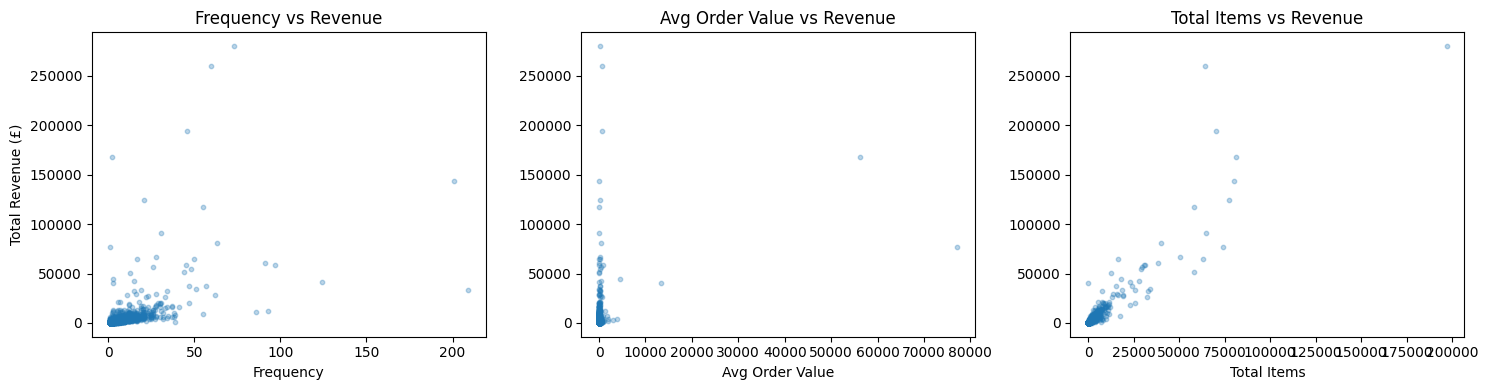

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(customers["Frequency"], customers["TotalRevenue"], alpha=0.3, s=10)
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Total Revenue (£)")
axes[0].set_title("Frequency vs Revenue")

axes[1].scatter(customers["AvgOrderValue"], customers["TotalRevenue"], alpha=0.3, s=10)
axes[1].set_xlabel("Avg Order Value")
axes[1].set_title("Avg Order Value vs Revenue")

axes[2].scatter(customers["TotalItems"], customers["TotalRevenue"], alpha=0.3, s=10)
axes[2].set_xlabel("Total Items")
axes[2].set_title("Total Items vs Revenue")

plt.tight_layout()
plt.savefig("../output/revenue_scatter.png", dpi=150)
plt.show()

In [3]:
# Remove top 1% outliers — they skew the model badly
q99 = customers["TotalRevenue"].quantile(0.99)
df_clean = customers[customers["TotalRevenue"] < q99].copy()
print(f"Rows after removing outliers: {len(df_clean)} (removed {len(customers) - len(df_clean)})")

# Features and target
X = df_clean[["Frequency", "AvgOrderValue", "TotalItems"]]
y = df_clean["TotalRevenue"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients — what the model learned
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(f"\nIntercept: {model.intercept_:.2f}")
print(coef_df.to_string(index=False))

Rows after removing outliers: 4294 (removed 44)

Intercept: -4.96
      Feature  Coefficient
    Frequency   122.229951
AvgOrderValue     0.643627
   TotalItems     1.094611


In [4]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  £{mae:.2f}")
print(f"RMSE: £{rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  £367.71
RMSE: £754.18
R²:   0.8659


**Actual vs Predicted plot**

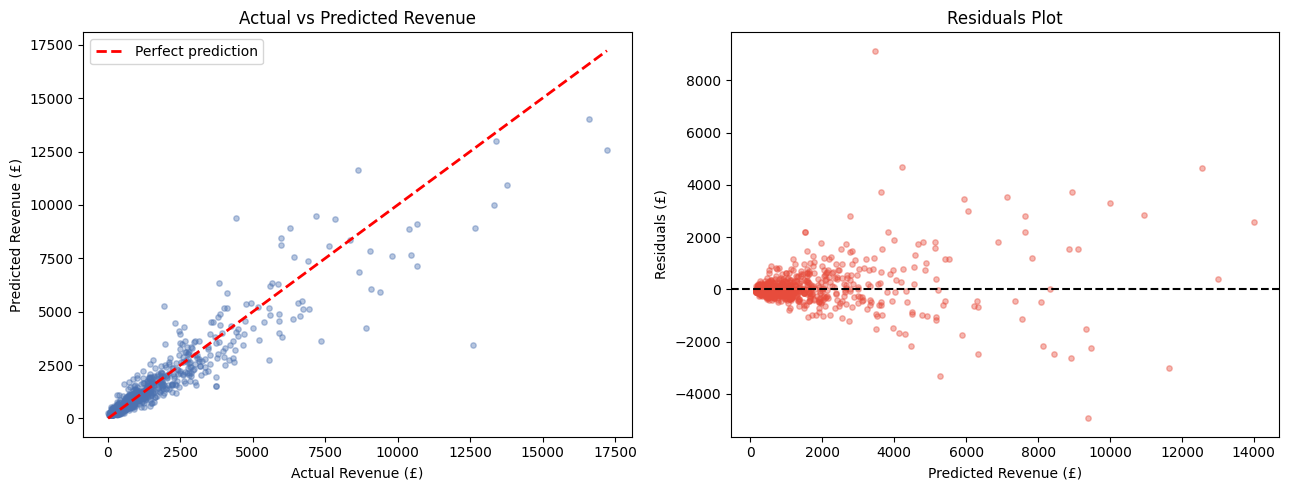

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color="#4C72B0")
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Revenue (£)")
axes[0].set_ylabel("Predicted Revenue (£)")
axes[0].set_title("Actual vs Predicted Revenue")
axes[0].legend()

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color="#e74c3c")
axes[1].axhline(y=0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted Revenue (£)")
axes[1].set_ylabel("Residuals (£)")
axes[1].set_title("Residuals Plot")

plt.tight_layout()
plt.savefig("../output/regression_evaluation.png", dpi=150)
plt.show()

In [6]:
# Predict revenue for a new customer
new_customer = pd.DataFrame({
    "Frequency": [10],
    "AvgOrderValue": [25],
    "TotalItems": [500]
})

predicted_revenue = model.predict(new_customer)[0]
print(f"Predicted Revenue for new customer: £{predicted_revenue:,.2f}")

# What if they order 20 times instead?
new_customer2 = pd.DataFrame({
    "Frequency": [20],
    "AvgOrderValue": [25],
    "TotalItems": [500]
})
predicted_revenue2 = model.predict(new_customer2)[0]
print(f"Predicted Revenue if frequency doubles: £{predicted_revenue2:,.2f}")
print(f"Difference: £{predicted_revenue2 - predicted_revenue:,.2f}")

Predicted Revenue for new customer: £1,780.73
Predicted Revenue if frequency doubles: £3,003.03
Difference: £1,222.30


In [7]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Scale features — important for Ridge and Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train all 3 models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=10)": Ridge(alpha=10),
    "Lasso (α=10)": Lasso(alpha=10)
}

results = []
for name, m in models.items():
    m.fit(X_train_scaled, y_train)
    y_pred_m = m.predict(X_test_scaled)
    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, y_pred_m), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_m)), 2),
        "R²": round(r2_score(y_test, y_pred_m), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model    MAE   RMSE     R²
Linear Regression 367.71 754.18 0.8659
     Ridge (α=10) 368.29 754.87 0.8656
     Lasso (α=10) 369.14 755.84 0.8653


In [8]:
coef_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Linear": LinearRegression().fit(X_train_scaled, y_train).coef_,
    "Ridge": Ridge(alpha=10).fit(X_train_scaled, y_train).coef_,
    "Lasso": Lasso(alpha=10).fit(X_train_scaled, y_train).coef_
})

print(coef_comparison.round(2).to_string(index=False))

      Feature  Linear   Ridge   Lasso
    Frequency  609.01  611.03  601.36
AvgOrderValue   76.72   77.20   67.01
   TotalItems 1449.47 1443.85 1445.78


In [9]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_r = ridge.predict(X_test_scaled)
    ridge_results.append({
        "Alpha": alpha,
        "R²": round(r2_score(y_test, y_pred_r), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_r)), 2)
    })

print(pd.DataFrame(ridge_results).to_string(index=False))

  Alpha     R²   RMSE
   0.01 0.8659 754.18
   0.10 0.8659 754.19
   1.00 0.8659 754.25
  10.00 0.8656 754.87
 100.00 0.8632 761.76
1000.00 0.8265 857.69
